In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math
import sklearn.mixture as mix
import emcee
import warnings; warnings.simplefilter('ignore')
import time
import corner

In [2]:
data=np.load('transient.npy')

<ErrorbarContainer object of 3 artists>

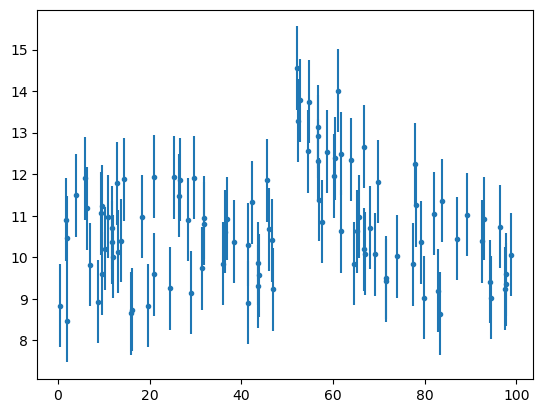

In [3]:
plt.errorbar(data[:,0],data[:,1],yerr=data[:,2],fmt='.')

In [4]:
b = 10             #background amplitude
A = 5              #burst amplitude
t0 = 50            #burst epoch
alpha = 0.12       #how rapidly the burst dies off
p = [b,A,t0,alpha] #joint parameter space

def model(p,t):
    array = np.full_like(t,1)
    array[t<p[2]] = p[0]
    array[t>=p[2]] = p[0] + (p[1]*np.exp(-p[3]*(t[t>=p[2]]-p[2])))
    return array

def ln_likelihood(p,t):
    return -0.5*np.sum(((data[:,1]-model(p,t))**2)/data[:,2]**2)
    #return -0.5*np.sum(((data[:,1]-model(p,t))**2)/data[:,2]**2 + np.log(2*np.pi*data[:,2]**2))
    #good to assume all gaussianly distributed because of the central limit theorem

def prior(p):
    if p[3] <= 0:
        return 0
    prior_b = stats.uniform.pdf(p[0], loc=0, scale=50)
    prior_A = stats.uniform.pdf(p[1], loc=0, scale=50)
    prior_t0 = stats.uniform.pdf(p[2], loc=0, scale=100)
    prior_lnalpha = stats.uniform.pdf(np.log(p[3]), loc=-5, scale=10)*(1/p[3])
    if prior_b*prior_A*prior_t0*prior_lnalpha == 0:
        return 0
    else:
        return prior_b*prior_A*prior_t0*prior_lnalpha
    

def posterior(p,t):
    return np.exp(ln_likelihood(p,t))*(prior(p))

def log_posterior(p,t):
    lp = np.log(prior(p))
    if not np.isfinite(lp):
        return -np.inf
    if not np.isfinite(ln_likelihood(p,t)):
        return -np.inf
    else:
        return ln_likelihood(p,t)+lp

In [5]:
ndim = 4         # number of parameters in the model
nwalkers = 10    # number of MCMC walkers
burn = 10000     # "burn-in" period to let chains stabilize
nsteps = 100000  # number of MCMC steps to take **for each walker**

# initialize parameters 
np.random.seed(0)
starting_guesses = np.array([b,A,t0,alpha])+1e-3*np.random.random((nwalkers, ndim))

# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[data[:,0]])
elapsed=time.time()
sampler.run_mcmc(starting_guesses, nsteps)
print(time.time()-elapsed)

# sampler.chain is of shape (nwalkers, nsteps, ndim)
# throw-out the burn-in points and reshape:
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

print("done")

488.1217954158783
done


Shape di samples: (90000, 10, 4)


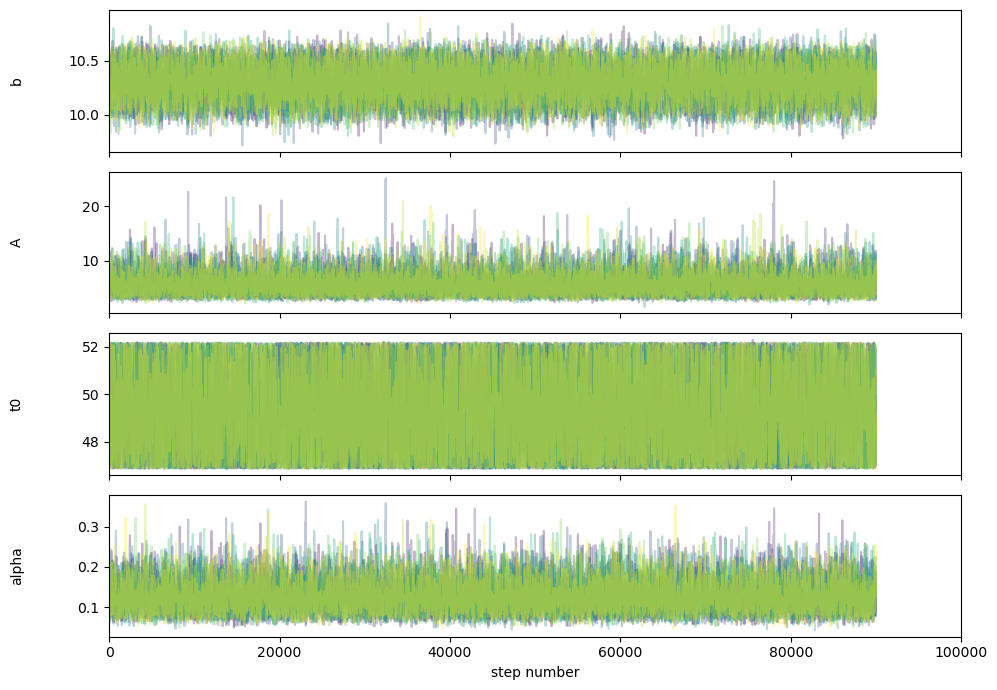

In [6]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain(discard=burn)
print(f"Shape di samples: {samples.shape}")
labels = ["b","A","t0","alpha"]
colors = plt.cm.viridis(np.linspace(0, 1, nwalkers))

for i in range(ndim):
    ax = axes[i]
    for j in range(nwalkers):
        ax.plot(samples[:, j, i], color=colors[j], alpha=0.3)
    ax.set_xlim(0, nsteps)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")
plt.tight_layout()
plt.show()

In [7]:
tau = sampler.get_autocorr_time()
print(tau)

[68.46210945 90.12264278 88.41667552 75.00281934]


(11250, 4)


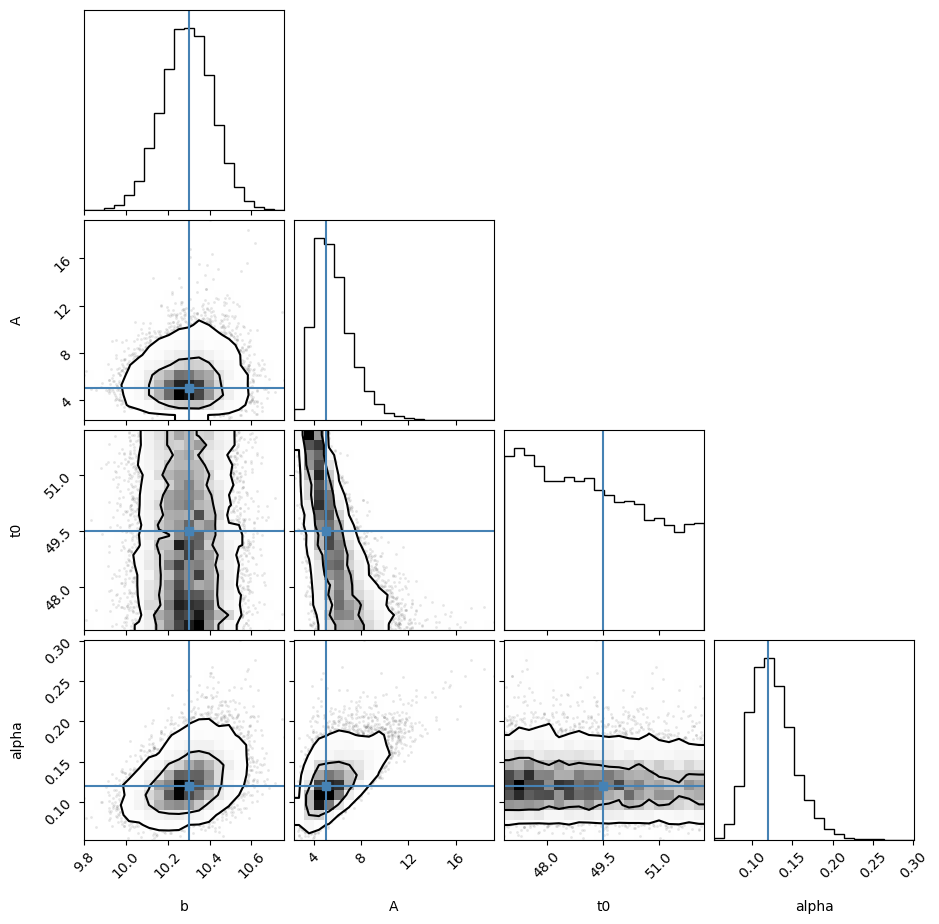

In [8]:
flat_samples = sampler.get_chain(discard=burn, thin=int(np.mean(tau)), flat=True)
print(flat_samples.shape)
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95],truths=[10.3,5,49.5,0.12])

- t0 very much constrained
- try to understand the correlations from the 2D plots

[10.29449001367356, 5.413277718767528, 49.12244056882665, 0.12243237418106408]


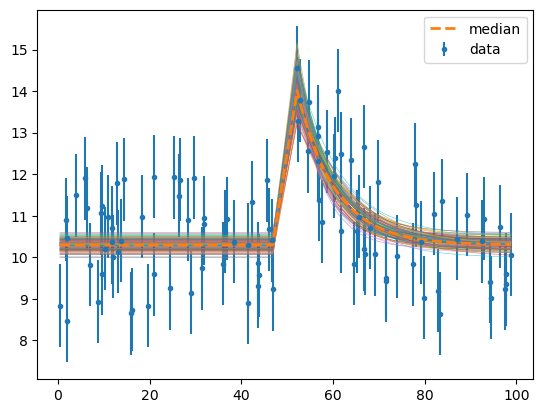

In [10]:
samp100 = flat_samples[np.random.choice(len(flat_samples), size=100)]
plt.errorbar(data[:,0],data[:,1],yerr=data[:,2],fmt='.',label='data')

for i in range(len(samp100)):
    y = model(samp100[i],data[:,0])
    plt.plot(data[:,0],y,alpha=0.6,lw=0.5)

medians = []
for i in range(len(flat_samples[0,:])):
    medians.append(np.median(flat_samples[:,i]))
print(medians)

plt.plot(data[:,0],model(medians,data[:,0]),'--',lw=2,label='median')
plt.legend()
plt.show()

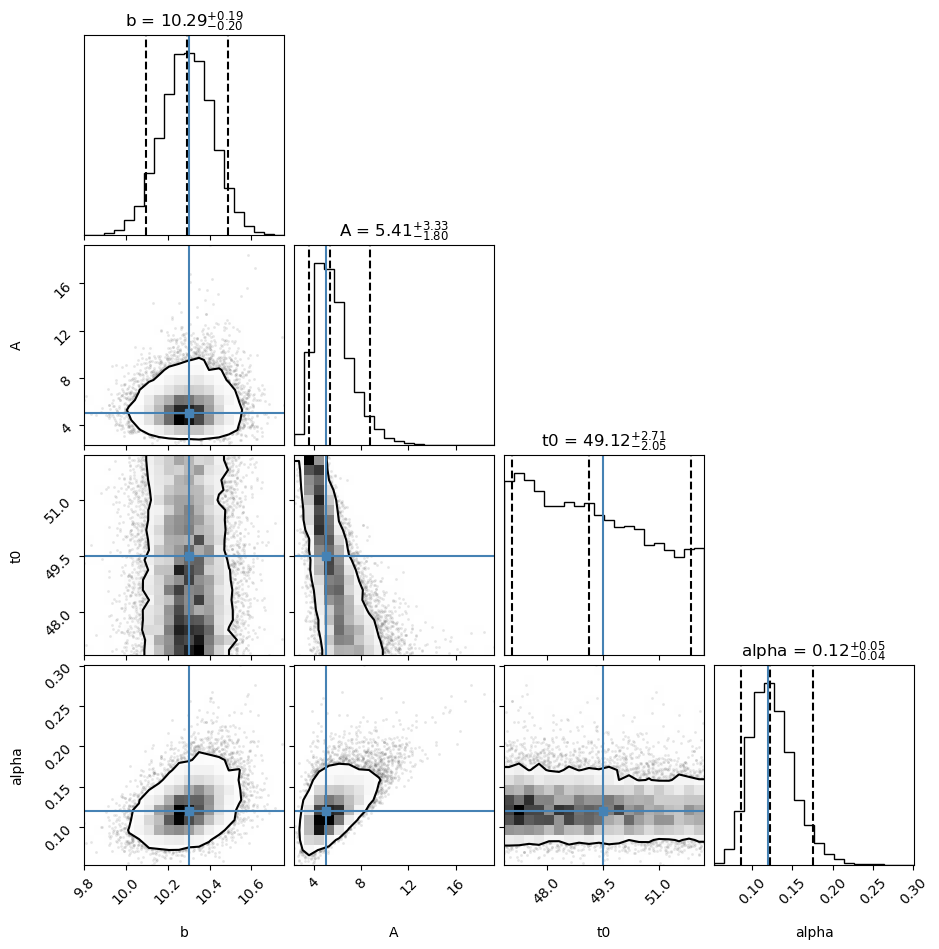

In [11]:
fig = corner.corner(flat_samples, labels=labels, levels=[0.90], truths=[10.3,5,49.5,0.12],
                    quantiles=[0.05,0.5,0.95], show_titles=True, title_kwargs={'fontsize':12})

# All what did but with Nested Sampling

In [13]:
time = data[:,0]
flux = data[:,1]
fluxerr = data[:,2]

def model_2(p2):
    t = time
    array = np.full_like(t,1)
    array[t<p2[2]] = p2[0]
    array[t>=p2[2]] = p2[0] + (p2[1]*np.exp(-(np.exp(p2[3]))*(t[t>=p2[2]]-p2[2]))) #p[3] è log_alpha!!
    return array

def ln_likelihood_2(p2):
    t = time
    #NEED TO BE NORMALIZED
    return -0.5*np.sum(((flux-model_2(p2))**2)/(fluxerr)**2 + np.log(2*np.pi*(fluxerr)**2))
    #good to assume all gaussianly distributed because of the central limit theorem

def prior_2(p2):
    if p2[3] <= 0:
        return 0
    prior_b = 50*p2[0]
    prior_A = 50*p2[1]
    prior_t0 = 100*p2[2]
    prior_lnalpha = 5*(2*p2[3] - 1) #p[3] è log_alpha
    return [prior_b,prior_A,prior_t0,prior_lnalpha]
    

def posterior_2(p2,t):
    return np.exp(ln_likelihood_2(p2,t))*(prior_2(p2))

def log_posterior_2(p2,t):
    lp_2 = np.log(prior_2(p2))
    if not np.isfinite(lp_2):
        return -np.inf
    if not ln_likelihood_2(p2,t):
        return -np.inf
    else:
        return ln_likelihood_2(p2,t)+lp_2

In [14]:
import dynesty
from dynesty import plotting as dyplot
sampler2 = dynesty.NestedSampler(ln_likelihood_2, prior_2, ndim)
sampler2.run_nested()
sresults2 = sampler2.results

7709it [01:14, 102.93it/s, +500 | bound: 155 | nc: 1 | ncall: 134334 | eff(%):  6.134 | loglstar:   -inf < -140.649 <    inf | logz: -155.281 +/-  0.168 | dlogz:  0.001 >  0.509]


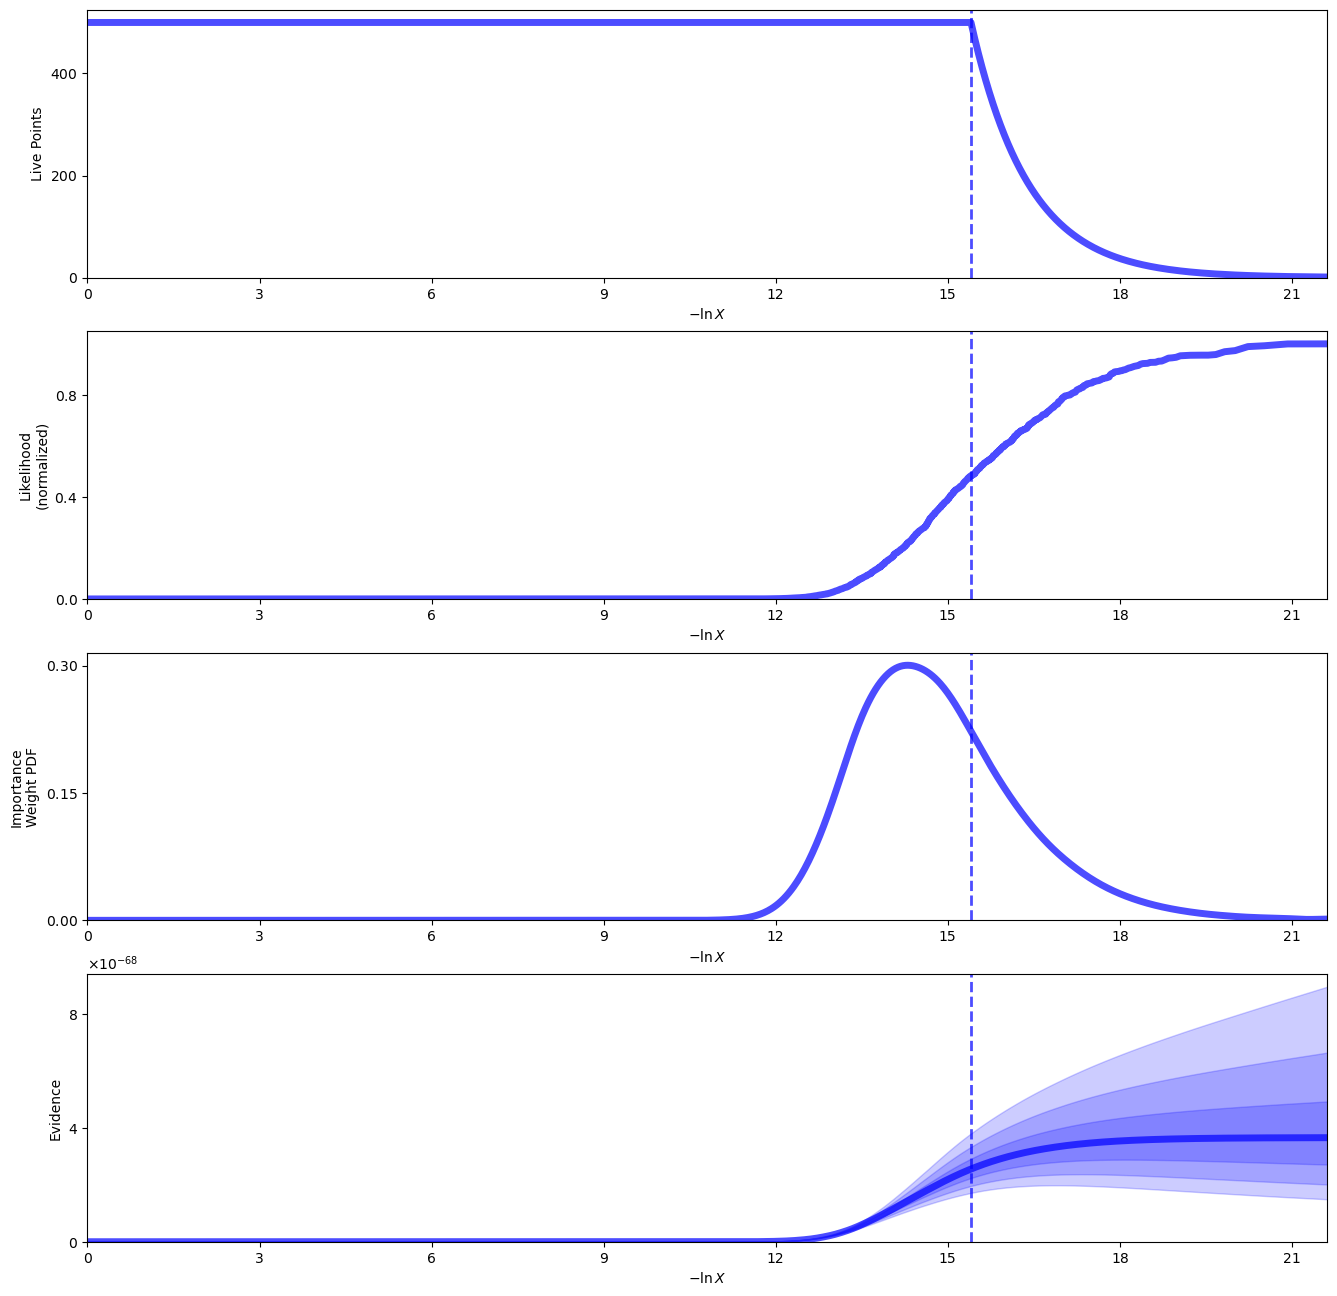

In [15]:
rfig, raxes = dyplot.runplot(sresults2)

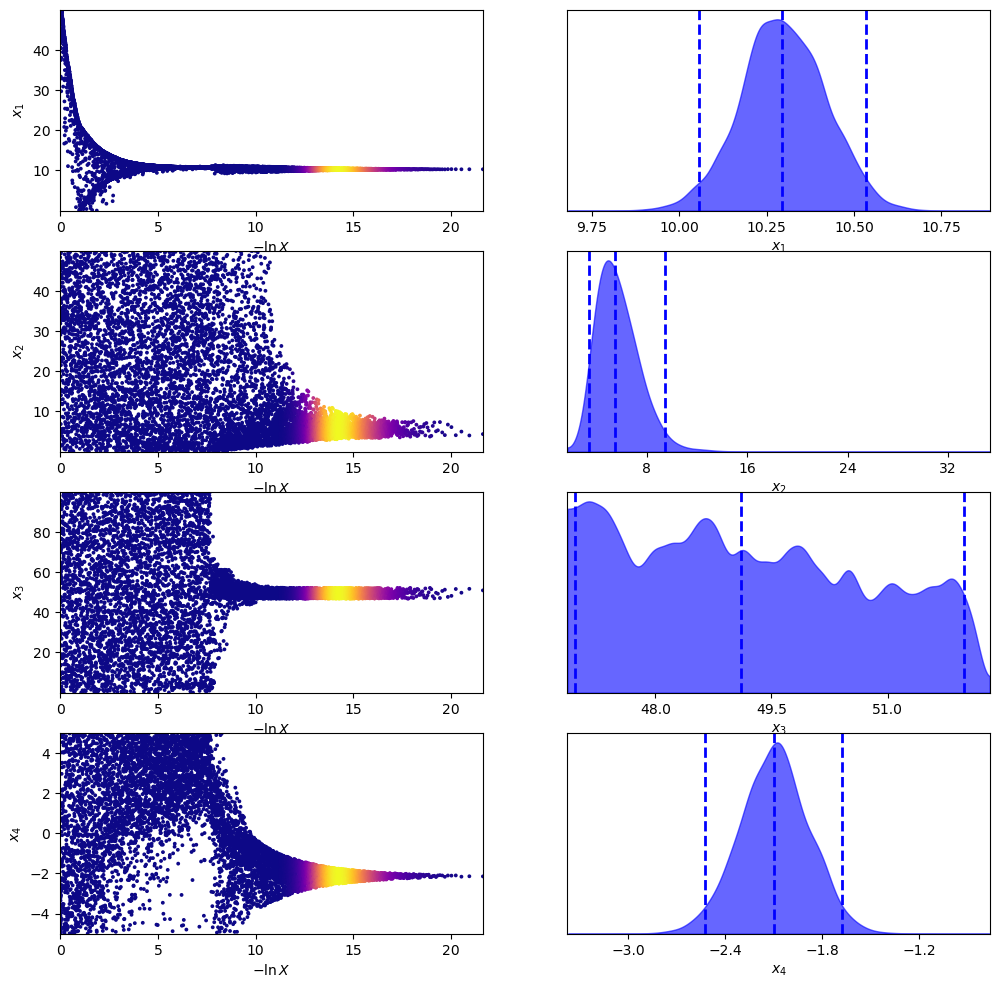

In [16]:
tfig, taxes = dyplot.traceplot(sresults2)

x1 = b = p2[0]; x2 = A = p2[1]; x3 = t0 = p2[2]; x4 = ln_alpha = p2[3]

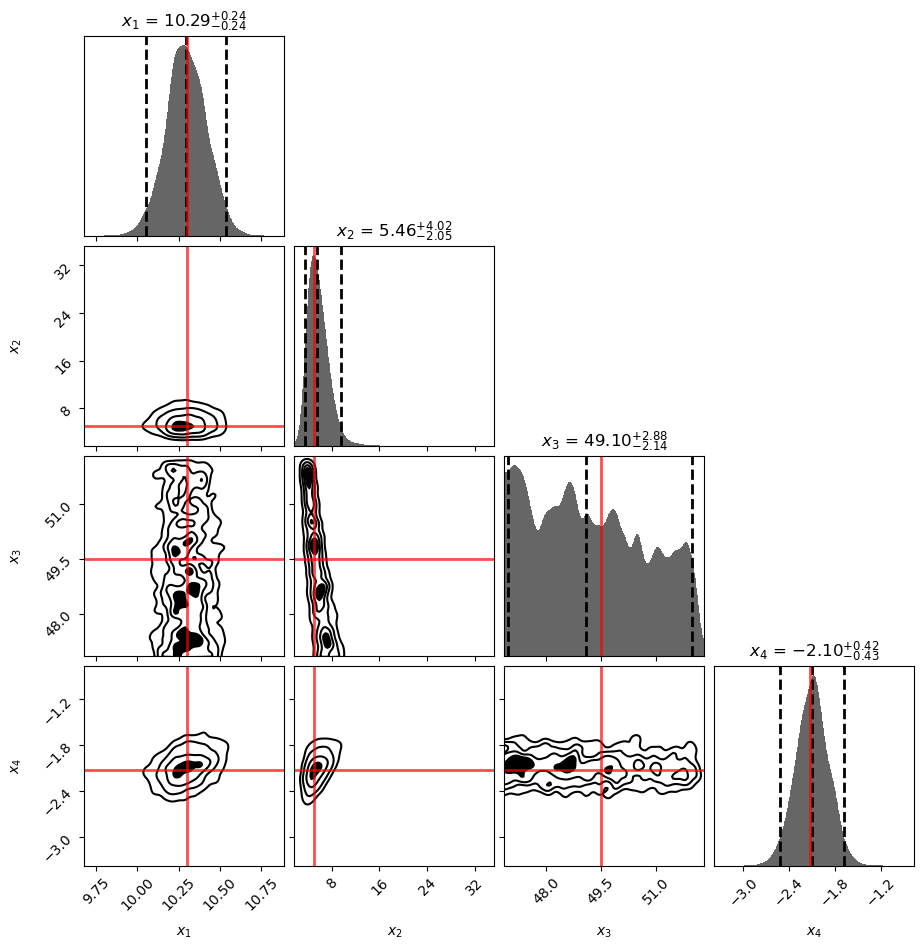

In [20]:
cfig, caxes = dyplot.cornerplot(sresults2, truths=[10.3,5,49.5,np.log(0.12)], show_titles=True)

In [30]:
sresults2.summary()

Summary
nlive: 500
niter: 7709
ncall: 133834
eff(%):  6.134
logz: -155.281 +/-  0.299


## Gaussian Model

In [21]:
def model3(p):
    t=time
    return p[0] + (p[1]*np.exp(-((t-p[2])**2)/(2*(np.exp(p[3]))**2)))
    #p[0]=b, p[1]=A, p[2]=t0, p[3]=sigma

def prior3(p):
    prior_b = 50*p[0]
    prior_A = 50*p[1]
    prior_t0 = 100*p[2]
    prior_lnsigma = 5*(2*p[3] - 1) #p[3] è log_sigma
    return [prior_b,prior_A,prior_t0,prior_lnsigma]

def ln_likelihood3(p):
    t = time
    #NEED TO BE NORMALIZED, already normalized(top)
    return -0.5*np.sum(((flux-model3(p))**2)/(fluxerr)**2 + np.log(2*np.pi*(fluxerr)**2))
    #good to assume all gaussianly distributed because of the central limit theorem

In [22]:
import dynesty
from dynesty import plotting as dyplot
sampler3 = dynesty.NestedSampler(ln_likelihood3, prior3, ndim)
sampler3.run_nested()
sresults3 = sampler3.results

8461it [02:29, 56.77it/s, +500 | bound: 261 | nc: 1 | ncall: 214526 | eff(%):  4.187 | loglstar:   -inf < -144.376 <    inf | logz: -160.552 +/-  0.179 | dlogz:  0.001 >  0.509] 


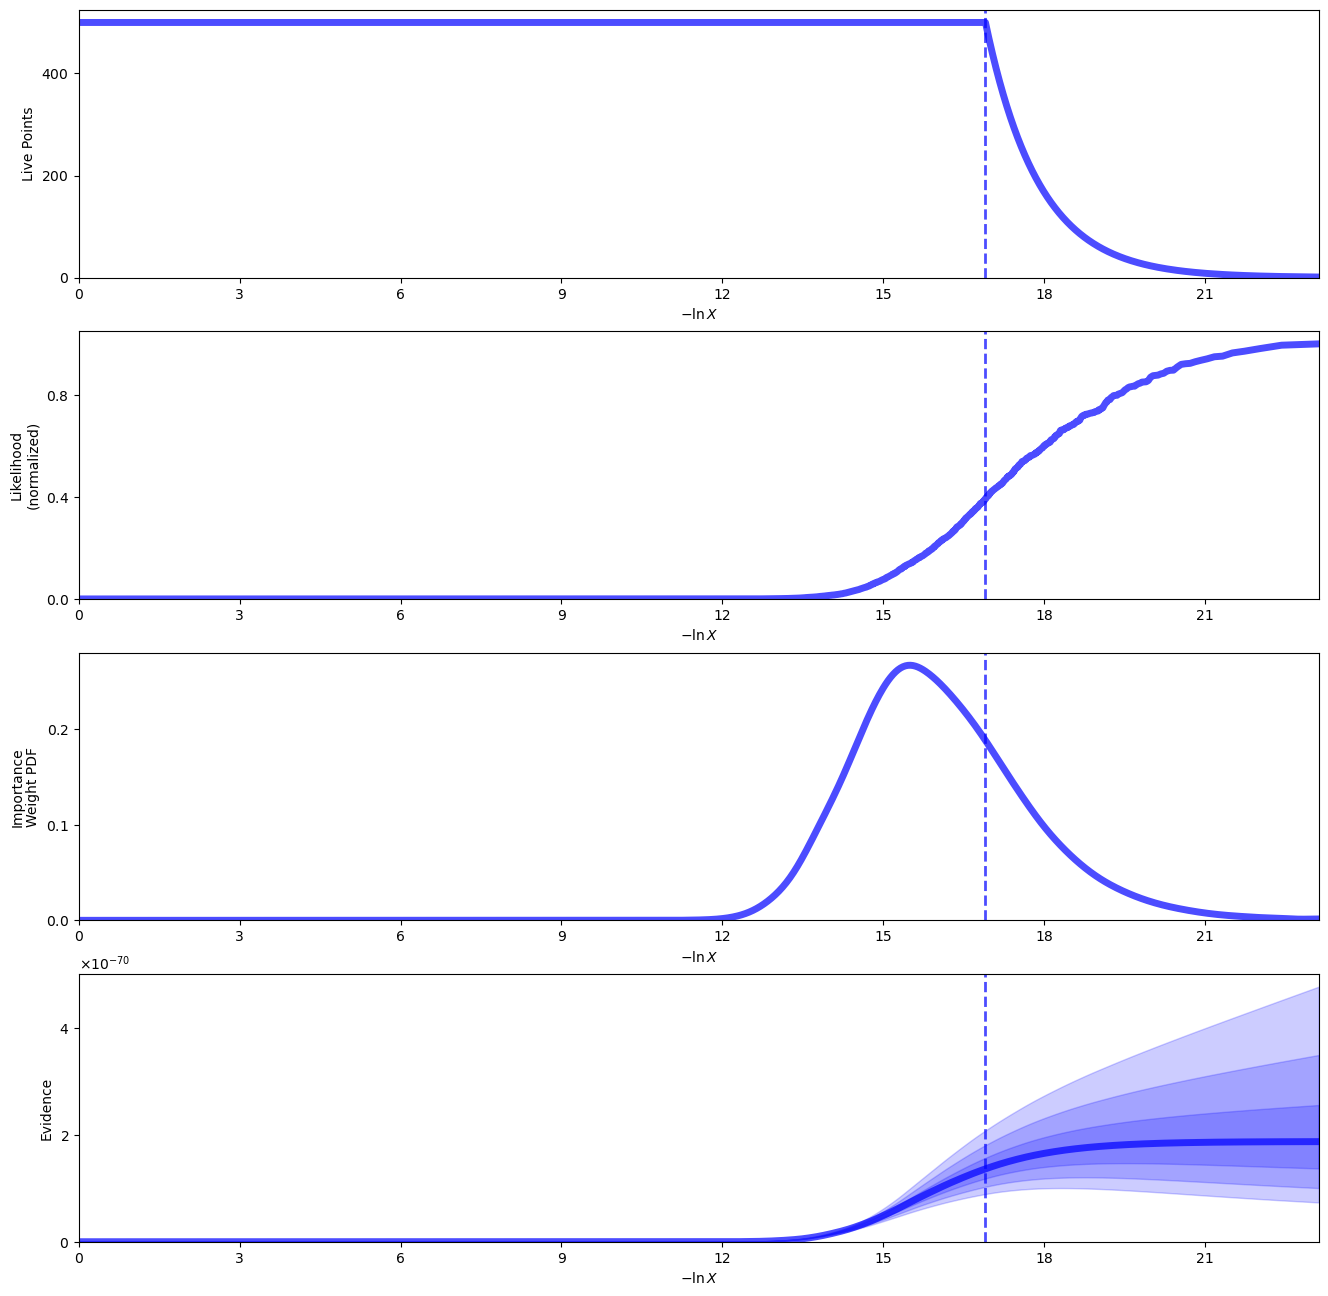

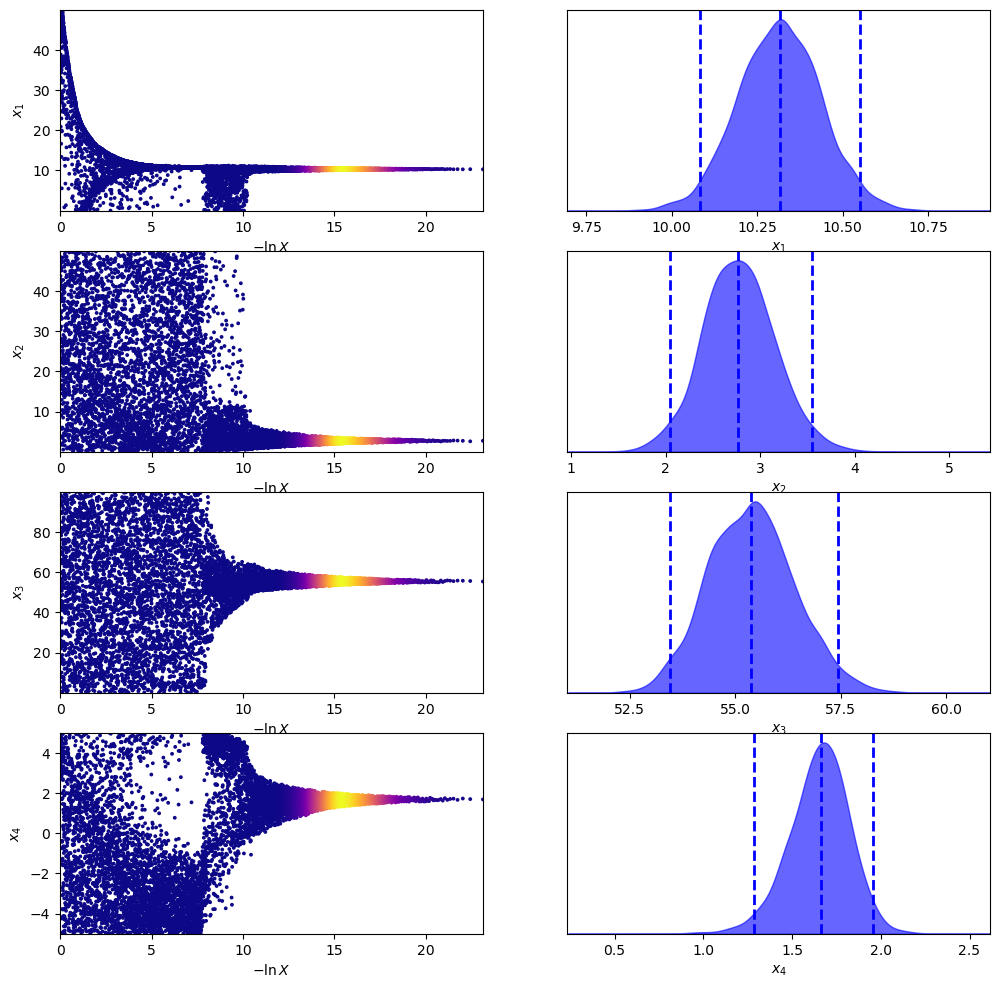

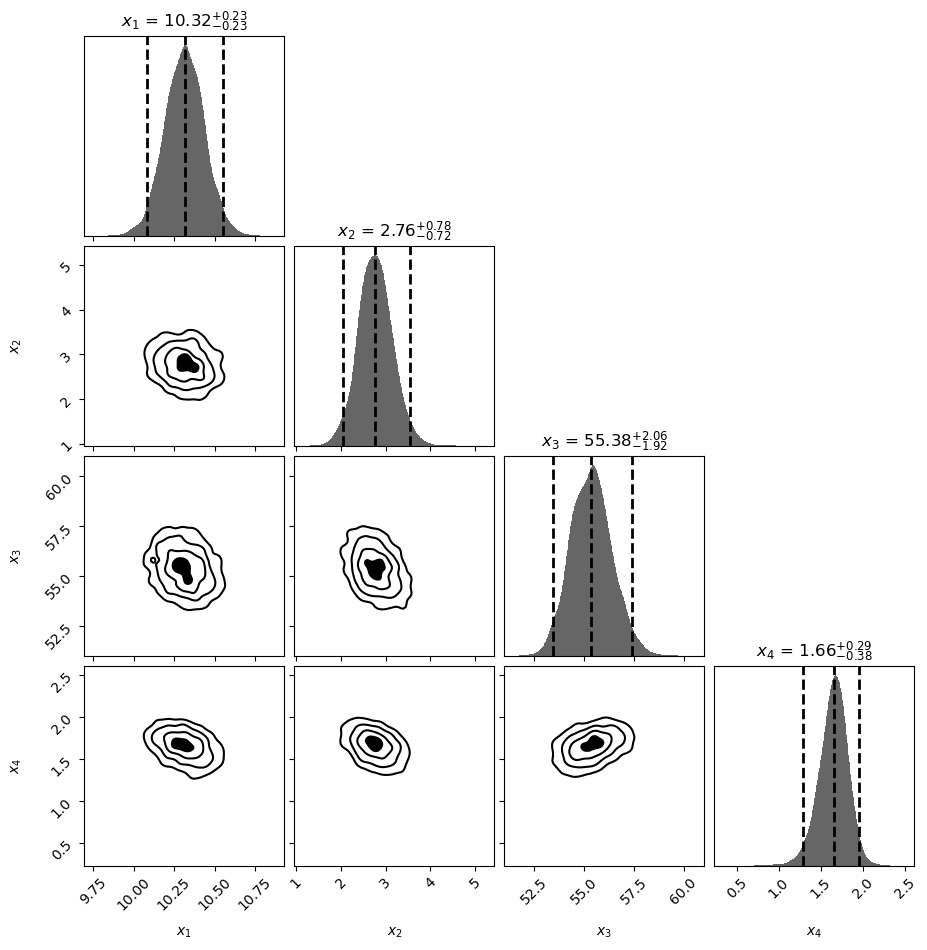

In [23]:
rfig, raxes = dyplot.runplot(sresults3)
tfig, taxes = dyplot.traceplot(sresults3)
cfig, caxes = dyplot.cornerplot(sresults3, show_titles=True)

In [29]:
sresults3.summary()

Summary
nlive: 500
niter: 8461
ncall: 214026
eff(%):  4.187
logz: -160.552 +/-  0.312


## Bayesian Evidence and Bayes Factor

In [28]:
be_m2 = np.exp(sresults2.logz[-1])
be_m3 = np.exp(sresults3.logz[-1])
print('Bayesian evidence of model 2:', be_m2, '\n', 'Bayesian evidence of model 3:', be_m3)

#Jeffrey's scale (odd ratio, since the two models have the same number of hyperpriors?)
b = be_m2/be_m3
print('Bayes Factor = ', b)

Bayesian evidence of model 2: 3.6510650194654073e-68 
 Bayesian evidence of model 3: 1.8760070850897558e-70
Bayes Factor =  194.61893552980507


Since it is > 100, we have stronge evidence that the first considered model (model 2) is better than the gaussian model(model 3)